# Sammenheng: avstemming, og dekningen som ikke ble nådd

Arbeidsverk 2, notebook 06. Bygger på notebook 04 (basismodellen) og 05 (intervallene).

Notebook 05 etterlot to ting. Prognosene for de seksten seriene **summerer ikke opp**:
bydelene prognostiseres hver for seg, og summen deres er ikke Oslo-prognosen. Og ingen
kalibrering nådde nominelt nivå — beste dekning var 73,7 mot 80.

Begge er spørsmål om sammenheng. Det første handler om at delene og helheten skal si
det samme. Det andre om at et intervall skal holde det det lover.


## 1. Oppsett


In [1]:
import os, subprocess, sys

def git(*a, standard=None):
    try:
        return subprocess.run(["git", *a], capture_output=True, text=True,
                              check=True, cwd=REPO).stdout.strip()
    except Exception:
        return standard

REPO = "/content/bostotte-oslo" if os.path.isdir("/content/bostotte-oslo") else "."
if not os.path.isdir(os.path.join(REPO, "data")):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/Torcode/bostotte-oslo.git",
                    "/content/bostotte-oslo"], check=True)
    REPO = "/content/bostotte-oslo"
elif REPO.startswith("/content"):
    git("fetch", "--depth", "1", "origin", "main"); git("reset", "--hard", "origin/main")

try: import torch
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"], check=True)
    import torch

COMMIT, UTTREKK = git("rev-parse", "--short", "HEAD", standard="ukjent"), "2026-08-04"
print("repo    :", os.path.abspath(REPO))
print("commit  :", COMMIT)
print("uttrekk :", UTTREKK)


repo    : /home/claude/bostotte-oslo
commit  : 4dd667c
uttrekk : 2026-08-04


In [2]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
KILDEAVTRYKK = "0acfdf55011b68803c237f238f3cee5891872d5150d47db8cb01180d310a4fe1"
FIL_MEG = "bostotte_06_avstemming.ipynb"
RAATT = f"https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/notebooks/{FIL_MEG}"
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         f"?path=notebooks/{FIL_MEG}&per_page=1")

import hashlib, json
import urllib.request, urllib.error

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=40):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""
try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    MANIFEST_HARMONI = "i harmoni" if paa_main == KILDEAVTRYKK else "avvik mot main"
    print(f"I harmoni med main{NAAR}." if paa_main == KILDEAVTRYKK else
          f"AVVIK mot main. denne {KILDEAVTRYKK[:16]}..., main {paa_main[:16]}...{NAAR}")
except urllib.error.HTTPError as e:
    MANIFEST_HARMONI = "finnes ikke paa main" if e.code == 404 else f"HTTP {e.code}"
    print("Notebooken ligger ikke paa main ennaa." if e.code == 404
          else f"Kontrollen fikk HTTP {e.code}.")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}).")


I harmoni med main.


## 2. Forhåndsregistreringen

Samme ordning som i notebook 05: påstandene ligger i `notebooks/forhandsregistrering_06.md`,
committet før noen modell her var kjørt.


In [3]:
FR_STI = "notebooks/forhandsregistrering_06.md"
FR_RAATT = f"https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/{FR_STI}"
FR_LOGG = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
           f"?path={FR_STI}&per_page=1")
try:
    with urllib.request.urlopen(FR_RAATT, timeout=40) as r:
        FR_TEKST = r.read().decode("utf-8")
    FR_SHA = hashlib.sha256(FR_TEKST.encode("utf-8")).hexdigest()
    print(f"Forhaandsregistreringen ligger paa main: {len(FR_TEKST)} tegn, "
          f"sha256 {FR_SHA[:16]}...")
except Exception as e:
    FR_SHA = f"ikke hentet ({type(e).__name__})"
    print(f"Naadde ikke forhaandsregistreringen ({type(e).__name__}).")
try:
    fr = hent(FR_LOGG)
    FR_COMMIT, FR_DATO = fr[0]["sha"][:7], fr[0]["commit"]["committer"]["date"]
    print(f"  committet {FR_DATO} som {FR_COMMIT}")
except Exception as e:
    FR_COMMIT, FR_DATO = "ukjent", "ukjent"
    print(f"  commit-datoen krever GitHubs API, som ikke svarte ({type(e).__name__}).")


Forhaandsregistreringen ligger paa main: 3800 tegn, sha256 042f61c84a7e6a1d...
  commit-datoen krever GitHubs API, som ikke svarte (HTTPError).


**Q1** — Avstemming gir liten gevinst for Oslo-totalen. *Felles hvis en avstemt
prognose slår den direkte med DM over 1,64 på noen av h = 1, 3, 6, 12.*

**Q2** — Bottom-up er dårligere enn direkte prognose for toppnivået. *Felles hvis
bottom-up har lavere MASE enn den direkte.*

**Q3** — Avstemming hjelper bunnnivået mer enn toppnivået. *Felles hvis
gjennomsnittlig MASE over bydelene ikke bedres.*

**Q4** — Endelig-utvalgskorreksjonen $\lceil (n+1)(1-\alpha)\rceil/n$ løfter
dekningen mest der kalibreringsgrunnlaget er tynt. *Felles hvis den ikke løfter
egen-historie-skjemaet, eller løfter panelskjemaet like mye.*


In [4]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import platform, importlib, time
import torch.nn as nn
torch.set_num_threads(max(1, os.cpu_count() or 2))

RAW = os.path.join(REPO, "data/raw/")
FIL = "husbanken_bostotte_oslo_manedlig.csv"

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = sha256(RAW + FIL)
NB05 = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
        "main/notebooks/bostotte_05_intervaller.ipynb")

def manifest_fra_notebook(url, noekkel):
    nb = hent(url, 60)
    for celle in reversed(nb["cells"]):
        if celle["cell_type"] == "code" and noekkel in "".join(celle["source"]):
            for u in celle.get("outputs", []):
                if u.get("output_type") == "stream":
                    return json.loads("".join(u["text"]))
    raise LookupError("fant ikke manifestet")

try:
    M05 = manifest_fra_notebook(NB05, 'MANIFEST["intervaller"]')
    assert M05["sjekksum"][FIL] == SJEKKSUM and M05["uttrekk"] == UTTREKK
    LENKE = "samme uttrekk og samme fil"
    NB05_DEKN = M05["intervaller"]["dekning_panel"]["L0"]
    print(f"Notebook 05 paa main, samme uttrekk. L0 med panelkalibrering: "
          f"{NB05_DEKN} % dekning.")
except Exception as e:
    LENKE, NB05_DEKN = f"ikke sjekket ({type(e).__name__})", None
    print(f"Naadde ikke notebook 05 ({type(e).__name__}).")

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
HARDT = chr(160)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round"})

def tusen(v, _=None):
    return f"{v:,.0f}".replace(",", HARDT)

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK, "python": platform.python_version(),
            "pakker": {}, "sjekksum": {FIL: SJEKKSUM}, "seed": SEED,
            "lenke_notebook05": LENKE,
            "forhaandsregistrering": {"commit": FR_COMMIT, "dato": FR_DATO,
                                      "sha256_fil": FR_SHA}}
for p in ["numpy", "pandas", "torch", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None
print("pakker:", MANIFEST["pakker"])


Notebook 05 paa main, samme uttrekk. L0 med panelkalibrering: 73.7 % dekning.
pakker: {'numpy': '2.4.4', 'pandas': '3.0.2', 'torch': '2.13.0+cpu', 'matplotlib': '3.10.9'}


## 3. Hierarkiet, og restnoden

Oslo er summen av femten bydeler pluss en ufordelt node `0301`. Før noe avstemmes må
det være klart hva som faktisk summerer til hva.


In [5]:
raa = pd.read_csv(RAW + FIL)
raa["dato"] = pd.to_datetime(dict(year=raa.aar, month=raa.manedsnr, day=1))
raa = raa.sort_values("dato").reset_index(drop=True)
kant = raa.index[(raa.dato == raa.dato.max()) & (raa.ant_husstander_termin == 0)]
est = raa.drop(index=kant); est = est[est.dato >= "2017-01-01"].reset_index(drop=True)
M, N_EST = est.set_index("dato")["ant_husstander_termin"].astype(float), len(est)
LOG_M = np.log(M)
MIN_TRENING, H_MAKS = 72, 12
OPPRINNELSER = [est.dato.iloc[i-1] for i in range(1, N_EST+1)
                if MIN_TRENING <= i <= N_EST - H_MAKS]
assert (len(OPPRINNELSER), N_EST) == (31, 114)

byd = pd.read_csv(RAW + "husbanken_bostotte_oslo_bydel_manedlig.csv",
                  dtype={"kommunenr": str})
byd["dato"] = pd.to_datetime(dict(year=byd.aar, month=byd.manedsnr, day=1))
PIV = byd.pivot_table(index="dato", columns="kommunenr",
                      values="ant_husstander_termin", aggfunc="sum")

alle_noder = (PIV.sum(axis=1) - M.reindex(PIV.index)).dropna()
uten_0301 = (PIV.drop(columns=["0301"]).sum(axis=1) - M.reindex(PIV.index)).dropna()
VINDU = slice(OPPRINNELSER[0] + pd.DateOffset(months=1),
              OPPRINNELSER[-1] + pd.DateOffset(months=H_MAKS))
rest_vindu = (-uten_0301).loc[VINDU]

print(f"sum(alle 16 noder) - Oslo : maks avvik {alle_noder.abs().max():.0f} "
      f"over {len(alle_noder)} maaneder")
print(f"restnoden 0301 i evalueringsvinduet: min {abs(rest_vindu.min()):.0f}, "
      f"maks {rest_vindu.max():.0f}, null i {(rest_vindu == 0).sum()} av {len(rest_vindu)}")
print(f"  som andel av Oslo: hoyst {100*rest_vindu.max()/M.loc[VINDU].min():.4f} %")
print(f"  rapportert fra og med: {PIV['0301'].last_valid_index():%Y-%m} og bakover")
assert rest_vindu.abs().max() <= 1


sum(alle 16 noder) - Oslo : maks avvik 0 over 114 maaneder
restnoden 0301 i evalueringsvinduet: min 0, maks 1, null i 40 av 42
  som andel av Oslo: hoyst 0.0064 %
  rapportert fra og med: 2025-08 og bakover


Restnoden er null i førti av førtito måneder i evalueringsvinduet og én husstand i de
to andre; siste måned den rapporteres i er august 2025.

Forhåndsregistreringen anslo september–desember litt feil — den sier «fra 2025m12» —
og det er verdt å la stå. En forhåndsregistrering som kan justeres i etterkant, binder
ingenting. Avviket har ingen følge for noe som regnes her. Hierarkiet
behandles derfor som Oslo lik summen av femten bydeler, med et dokumentert avvik på
høyst én husstand — under 0,01 prosent. `assert`-en holder det fast, slik at et
framtidig uttrekk der restnoden våkner til liv, stopper kjøringen framfor å bli
avstemt bort.


## 4. Basisprognoser for alle nodene

Samme oppsett som notebook 05: én global lineær modell per kombinasjon av
opprinnelse og horisont, trent på hele panelet i kommunenummerrekkefølge, og
prognoser for alle seksten nodene fra den samme tilpasningen.

**Avstemming er en lineær operasjon og må derfor gjøres på nivåskala.** Modellene
arbeider på logskala, og summen av logaritmer er ikke logaritmen av summen. Alt
under er derfor eksponentiert først.


In [6]:
mnd_alle = pd.date_range("2010-01-01", "2027-12-01", freq="MS")
X = pd.DataFrame(index=mnd_alle)
X["win_covid"] = ((mnd_alle >= "2020-04-01") & (mnd_alle <= "2020-10-01")).astype(int)
X["win_strom"] = ((mnd_alle >= "2021-12-01") & (mnd_alle <= "2024-03-01")).astype(int)
X["pakke_2024h2"] = (((mnd_alle >= "2024-07-01").astype(int)
                      + (mnd_alle >= "2024-09-01").astype(int)
                      + (mnd_alle >= "2024-10-01").astype(int)) / 3)

def u_av_fase(fase=0, fra=pd.Timestamp("2010-01-01"), til=pd.Timestamp("2027-12-31")):
    anker = pd.Timestamp("2014-01-06") + pd.Timedelta(days=fase)
    start = anker - pd.Timedelta(days=14*int(np.ceil((anker - fra).days/14)))
    d = pd.date_range(start, til, freq="14D"); d = d[d >= fra]
    return pd.Series(d).dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

u = u_av_fase().reindex(mnd_alle)
X["k_pre"]  = (u - 26/12) * (mnd_alle <= "2024-12-01").astype(int)
X["k_post"] = (u - 26/12) * (mnd_alle >= "2025-01-01").astype(int)
REG, MIN_NZ, LAG = list(X.columns), 6, [1, 2, 3, 6, 11, 12]

def trekk(serie, s):
    v = serie.loc[:s]
    if len(v) < 13: return None
    d = np.diff(np.log(v.values))
    ut = {f"lag{l}": np.log(v.iloc[-1-l]) - np.log(v.iloc[-1]) for l in LAG}
    ut["niva"] = np.log(v.iloc[-1]); ut["d1"] = d[-1]
    ut["d12"] = np.log(v.iloc[-1]) - np.log(v.iloc[-13])
    ut["sd6"] = d[-6:].std(); ut["sd12"] = d[-12:].std(); ut["snitt6"] = d[-6:].mean()
    return ut

def historikk(serie):
    r = {s: trekk(serie, s) for s in serie.index}
    return pd.DataFrame({s: v for s, v in r.items() if v is not None}).T

bydel_serier = {k: PIV[k].dropna() for k in PIV.columns if k != "0301"}
bydel_serier = {k: v[(v > 0) & (v.index >= "2017-01-01")]
                for k, v in bydel_serier.items()}
SERIER = {"OSLO": M, **bydel_serier}
BUNN = sorted(bydel_serier)                 # kommunenummer, fast
NODER = ["OSLO"] + BUNN
HIST = {k: historikk(v) for k, v in SERIER.items()}
KOL = list(HIST["OSLO"].columns) + ["mnd"] + REG
SUM = np.vstack([np.ones(len(BUNN)), np.eye(len(BUNN))])     # 16 x 15

NEVNER = {navn: {t0: np.abs(SERIER[navn].loc[:t0].values[12:]
                            - SERIER[navn].loc[:t0].values[:-12]).mean()
                 for t0 in OPPRINNELSER} for navn in NODER}
assert round(np.mean([abs(M.loc[t0 + pd.DateOffset(months=h)]
                          - M.loc[t0])/NEVNER["OSLO"][t0]
                      for t0 in OPPRINNELSER for h in range(1, 13)]), 3) == 1.003
print("Protokollen kontrollert: naiv referanse gir MASE 1,003 som i arbeidsverk 1.")

def sett(navn, t0, h, aktive):
    s, hh = SERIER[navn], HIST[navn]
    kilder = hh.index[hh.index + pd.DateOffset(months=h) <= t0]
    kilder = kilder[[k + pd.DateOffset(months=h) in s.index for k in kilder]]
    if len(kilder) == 0: return None, None
    maalmnd = kilder + pd.DateOffset(months=h)
    D = hh.loc[kilder].copy(); D["mnd"] = maalmnd.month
    for r in REG: D[r] = X.loc[maalmnd, r].values if r in aktive else 0.0
    return (D[KOL].to_numpy(dtype=float),
            np.log(s.loc[maalmnd].values) - np.log(s.loc[kilder].values))

def prediksjonsrad(navn, t0, h, aktive):
    m_ = t0 + pd.DateOffset(months=h)
    if t0 not in HIST[navn].index or m_ not in SERIER[navn].index: return None
    d = HIST[navn].loc[[t0]].copy(); d["mnd"] = m_.month
    for r in REG: d[r] = X.loc[m_, r] if r in aktive else 0.0
    return d[KOL].to_numpy(dtype=float)

EPOKER, LR, WD = 400, 1e-2, 1e-4
def lineaer(Xg, yg, Xpr):
    mx, sx = Xg.mean(0), Xg.std(0) + 1e-9
    my, sy = yg.mean(), yg.std() + 1e-9
    Xn = torch.tensor((Xg - mx)/sx, dtype=torch.float32)
    yn = torch.tensor((yg - my)/sy, dtype=torch.float32).view(-1, 1)
    Pn = torch.tensor((Xpr - mx)/sx, dtype=torch.float32)
    torch.manual_seed(SEED)
    m = nn.Linear(Xn.shape[1], 1)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WD); f = nn.MSELoss()
    for _ in range(EPOKER):
        opt.zero_grad(); l = f(m(Xn), yn); l.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return m(Pn).numpy().ravel()*sy + my

t_start, rader = time.time(), []
for t0 in OPPRINNELSER:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    for h in range(1, H_MAKS + 1):
        Xs, ys = [], []
        for navn in NODER:
            a, b = sett(navn, t0, h, aktive)
            if a is not None: Xs.append(a); ys.append(b)
        vekst = lineaer(np.vstack(Xs), np.concatenate(ys),
                        np.vstack([prediksjonsrad(n, t0, h, aktive) for n in NODER]))
        m_ = t0 + pd.DateOffset(months=h)
        rad = {"opprinnelse": t0, "h": h, "dato": m_}
        for i, navn in enumerate(NODER):
            rad[f"p_{navn}"] = float(np.exp(np.log(SERIER[navn].loc[t0]) + vekst[i]))
            rad[f"y_{navn}"] = float(SERIER[navn].loc[m_])
        rader.append(rad)

B = pd.DataFrame(rader)
P0 = B[[f"p_{n}" for n in NODER]].to_numpy()
Y  = B[[f"y_{n}" for n in NODER]].to_numpy()
inkoh = P0[:, 1:].sum(axis=1) - P0[:, 0]
print(f"{len(B)} prognosepunkter per node, {time.time()-t_start:.0f} s")
print(f"inkoherens foer avstemming: median {np.median(np.abs(inkoh)):.0f} husstander, "
      f"maks {np.abs(inkoh).max():.0f} "
      f"({100*np.median(np.abs(inkoh)/P0[:, 0]):.2f} % av totalen)")


Protokollen kontrollert: naiv referanse gir MASE 1,003 som i arbeidsverk 1.


372 prognosepunkter per node, 78 s
inkoherens foer avstemming: median 280 husstander, maks 477 (1.51 % av totalen)


Basisprognosene bommer på seg selv med rundt 280 husstander, halvannen prosent av
totalen. Det er ikke en modellfeil — Oslo-prognosen og bydelsprognosene er laget av
samme modell, men uavhengig av hverandre, og ingenting i konstruksjonen tvinger dem
til å stemme. En etat som får utlevert begge deler, vil se to tall som ikke går opp.


## 5. Fire måter å avstemme på

**Bottom-up** erstatter toppen med summen av bunnen. **Top-down** fordeler toppen
etter historiske andeler, målt i treningsvinduet ved hver opprinnelse. **MinT** løser
$\tilde{y} = S(S'W^{-1}S)^{-1}S'W^{-1}\hat{y}$ og velger den koherente prognosen som
er nærmest basisprognosen i en metrikk gitt av $W$ — feilenes kovariansmatrise. Med
$W = I$ blir det ren minste kvadraters projeksjon; med $W$ estimert fra realiserte
feil blir det MinT slik Wickramasuriya m.fl. (2019) definerer den.

Kovariansmatrisen estimeres **tidsgyldig**: bare på feil som var realisert ved
opprinnelsen. Seksten noder gir 136 frie parametre i $W$, og ved de tidligste
opprinnelsene finnes tre observasjoner. Derfor krympes den mot diagonalen med
Schäfer–Strimmer-intensitet.


In [7]:
def krymping(E):
    n, p = E.shape
    S_ = np.cov(E, rowvar=False, ddof=1)
    d = np.sqrt(np.diag(S_)) + 1e-12
    Rk = S_ / np.outer(d, d)
    Z = (E - E.mean(0)) / (E.std(0, ddof=1) + 1e-12)
    varR = np.einsum("ti,tj->tij", Z, Z).var(axis=0, ddof=1) * n / (n - 1)**2
    iu = np.triu_indices(p, 1)
    lam = float(np.clip(varR[iu].sum() / max((Rk[iu]**2).sum(), 1e-12), 0, 1))
    return np.outer(d, d) * ((1 - lam)*Rk + lam*np.eye(p)), lam

def avstem(yhat, W):
    Wi = np.linalg.pinv(W)
    return SUM @ (np.linalg.pinv(SUM.T @ Wi @ SUM) @ SUM.T @ Wi @ yhat)

ANDEL = {t0: (lambda v: v/v.sum())(
             np.array([SERIER[k].loc[:t0].tail(12).sum() for k in BUNN], float))
         for t0 in OPPRINNELSER}

METODER = {"basis": P0.copy()}
bu = P0.copy(); bu[:, 0] = P0[:, 1:].sum(axis=1)
METODER["bottom-up"] = bu
td = P0.copy()
for i, t0 in enumerate(B.opprinnelse):
    td[i, 1:] = P0[i, 0] * ANDEL[t0]
METODER["top-down"] = td

feil = P0 - Y
ols = np.zeros_like(P0); mt = np.zeros_like(P0); lam_liste = []
realisert = B.opprinnelse + B.h.apply(lambda x: pd.DateOffset(months=int(x)))
for i in range(len(B)):
    ols[i] = avstem(P0[i], np.eye(len(NODER)))
    m = (realisert <= B.opprinnelse.iloc[i]).values & (B.h == B.h.iloc[i]).values
    E = feil[m]
    if len(E) >= 3:
        W, lam = krymping(E - E.mean(0)); lam_liste.append(lam)
    else:
        W = np.eye(len(NODER))
    mt[i] = avstem(P0[i], W)
METODER["MinT-OLS"] = ols
METODER["MinT-krymp"] = mt
print(f"krympingsintensitet: median {np.median(lam_liste):.2f}, "
      f"{len(lam_liste)} av {len(B)} punkter med estimert W")

def mase(Yhat, j):
    q = np.array([NEVNER[NODER[j]][t0] for t0 in B.opprinnelse])
    return np.mean(np.abs(Yhat[:, j] - Y[:, j]) / q)

res = pd.DataFrame([
    dict(metode=navn, MASE_Oslo=mase(Yh, 0),
         MASE_bydel=np.mean([mase(Yh, j) for j in range(1, len(NODER))]),
         inkoherens=np.abs(Yh[:, 1:].sum(axis=1) - Yh[:, 0]).max())
    for navn, Yh in METODER.items()]).set_index("metode").round(
    {"MASE_Oslo": 4, "MASE_bydel": 4, "inkoherens": 1})
res.index.name = None
res


krympingsintensitet: median 0.15, 270 av 372 punkter med estimert W


,MASE_Oslo,MASE_bydel,inkoherens
basis,0.7671,0.8364,476.9
bottom-up,0.8250,0.8364,0.0
top-down,0.7671,0.7983,0.0
MinT-OLS,0.7698,0.7972,0.0
MinT-krymp,0.7961,0.8177,0.0


In [8]:
def dm_harvey(ea, eb, h, hvec):
    m = hvec == h
    e1, e2 = ea[m], eb[m]; n = len(e1)
    d = e1**2 - e2**2; dc = d - d.mean()
    g = np.array([(dc[:n-k]*dc[k:]).sum()/n for k in range(h)])
    v = (g[0] + 2*g[1:].sum())/n
    if not np.isfinite(v) or v <= 0: return np.nan
    return (d.mean()/np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)

hv = B.h.values
rad = []
for navn in ["bottom-up", "top-down", "MinT-OLS", "MinT-krymp"]:
    Yh = METODER[navn]
    topp = [dm_harvey(P0[:, 0] - Y[:, 0], Yh[:, 0] - Y[:, 0], h, hv) for h in [1, 3, 6, 12]]
    ea = np.concatenate([P0[:, j] - Y[:, j] for j in range(1, len(NODER))])
    eb = np.concatenate([Yh[:, j] - Y[:, j] for j in range(1, len(NODER))])
    hb = np.tile(hv, len(NODER) - 1)
    bunn = [dm_harvey(ea, eb, h, hb) for h in [1, 3, 6, 12]]
    rad.append(dict(metode=navn, **{f"Oslo h{h}": v for h, v in zip([1, 3, 6, 12], topp)},
                    **{f"bydel h{h}": v for h, v in zip([1, 3, 6, 12], bunn)}))
DM = pd.DataFrame(rad).set_index("metode").round(2)
DM.index.name = None
print("Positiv verdi favoriserer avstemming. Ensidig kritisk verdi: 1,64.\n")
DM


Positiv verdi favoriserer avstemming. Ensidig kritisk verdi: 1,64.



,Oslo h1,Oslo h3,Oslo h6,Oslo h12,bydel h1,bydel h3,bydel h6,bydel h12
bottom-up,-1.54,-1.65,-1.20,-0.89,NaN,NaN,NaN,NaN
top-down,NaN,NaN,NaN,NaN,-0.66,3.42,2.97,2.59
MinT-OLS,-1.21,-1.38,-1.03,-0.48,5.38,5.64,4.27,2.99
MinT-krymp,-1.24,-1.18,-0.55,-0.88,6.90,5.26,4.59,0.77


To celler i tabellen er tomme, og det er en kontroll framfor et hull. Bottom-up rører
ikke bydelene — den bytter bare ut toppen med summen — så tapsdifferansen der er
identisk null og en teststatistikk kan ikke dannes. Top-down rører ikke toppen, med
samme følge. Hadde noen av de fire cellene hatt et tall, ville metodene gjort noe de
per konstruksjon ikke skal gjøre.

Ellers er bildet entydig, og det peker i to retninger samtidig.

**For Oslo-totalen er alle fire metodene dårligere enn å la prognosen stå.** Ingen
DM-verdi er positiv. Bottom-up er verst, med MASE 0,825 mot 0,767 og en statistikk på
−1,65 ved h = 3, altså på grensen til å være signifikant *i disfavør*. **Q1 holdt** —
ingen metode slår den direkte prognosen med statistikk over 1,64 — og **Q2 holdt**:
summen av femten prognoser for serier på under to tusen mottakere er en dårligere
prognose for sytten tusen enn en modell som prognostiserer sytten tusen.

**For bydelene er bildet motsatt, og det er den sterkeste effekten i hele arbeidsverk
2.** MinT med $W = I$ senker gjennomsnittlig MASE fra 0,836 til 0,797, og
DM-statistikken er 5,4 ved h = 1 og 3,0 ved h = 12 — godt over 1,64 på alle fire
horisonter. Ingenting i notebook 03, 04 eller 05 var i nærheten av å være så tydelig.
**Q3 holdt.**

Grunnen er den samme som i notebook 04, sett fra en annen kant: den velestimerte
totalen har mye å gi de støyende bydelene, og bydelene har lite å gi totalen.
Avstemming er derfor **ikke en måte å forbedre totalen på. Det er en måte å forbedre
delene på**, og prisen er en liten forverring på toppen.

**MinT med estimert kovarians er dårligere enn MinT med $W = I$**, både på toppen
(0,796 mot 0,770) og i bunnen (0,818 mot 0,797). Krympingsintensiteten lander på 0,15
i median, altså brukes i hovedsak den rå kovariansen — og den er estimert på så få
punkter at den bærer mer støy enn informasjon. Det er en praktisk grense ved MinT som
teorien ikke fanger: optimaliteten forutsetter en $W$ man her ikke kan estimere.


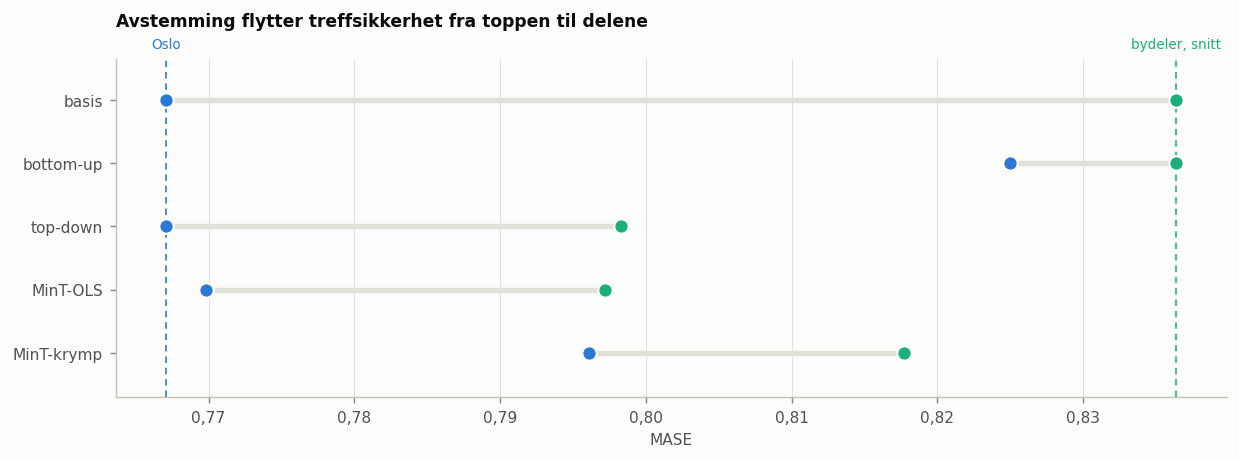

In [9]:
fig, ax = plt.subplots(figsize=(9.6, 3.6))
navn = list(METODER)
xo = [res.MASE_Oslo[n] for n in navn]
xb = [res.MASE_bydel[n] for n in navn]
y = np.arange(len(navn))[::-1]
for i, n in enumerate(navn):
    ax.plot([xo[i], xb[i]], [y[i], y[i]], color=RUTE, lw=3.0,
            solid_capstyle="round", zorder=2)
    ax.plot(xo[i], y[i], "o", ms=8, color=SERIE[0], zorder=4,
            markeredgecolor="#fcfcfb", markeredgewidth=1.2)
    ax.plot(xb[i], y[i], "o", ms=8, color=SERIE[2], zorder=4,
            markeredgecolor="#fcfcfb", markeredgewidth=1.2)
ax.axvline(xo[0], color=SERIE[0], lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.axvline(xb[0], color=SERIE[2], lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.set_yticks(y, navn)
ax.set_xlabel("MASE")
ax.set_title("Avstemming flytter treffsikkerhet fra toppen til delene", pad=18)
ax.grid(axis="y", visible=False)
ax.annotate("Oslo", xy=(xo[0], 1.0), xycoords=("data", "axes fraction"),
            xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=SERIE[0], annotation_clip=False)
ax.annotate("bydeler, snitt", xy=(xb[0], 1.0), xycoords=("data", "axes fraction"),
            xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=SERIE[2], annotation_clip=False)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:.2f}".replace(".", ",")))
ax.set_ylim(-0.7, len(navn) - 0.35)
fig.tight_layout(); plt.show()


De stiplede linjene er basisprognosen. Alt til venstre for dem er bedre, alt til
høyre dårligere. Blå prikker beveger seg høyresover — toppen taper — mens grønne
beveger seg venstresover for tre av fire metoder.


## 6. Q4: en korreksjon som mangler i notebook 02 og 05

Konformale intervaller i notebook 02 og 05 bruker den empiriske kvantilen til de
kalibrerte feilene direkte. Det er ikke helt riktig. Split-konformal prediksjon gir
endelig-utvalgsgaranti bare når nivået settes til

$$\frac{\lceil (n+1)(1-\alpha) \rceil}{n},$$

altså litt høyere enn $1-\alpha$. Med $n = 304$ er forskjellen forsvinnende, 0,803 mot
0,800. Med $n = 19$ er den ikke det: 0,842. Og med $n = 3$ overstiger uttrykket 1, som
betyr at ingen 80-prosents garanti kan gis — intervallet må da dekke hele spennet av
observerte feil.

Rettelsen skal derfor slå ut i skjemaet som kalibrerer på Oslos egen historie, og
nesten ikke i panelskjemaet.


In [10]:
RL = B[["opprinnelse", "h", "dato"]].copy()
for j, n in enumerate(NODER):
    RL[f"lf_{n}"] = np.log(Y[:, j]) - np.log(P0[:, j])
lang = RL.melt(id_vars=["opprinnelse", "h", "dato"], var_name="serie", value_name="lf")
lang["serie"] = lang.serie.str.removeprefix("lf_")
ALFA, MIN_KAL = 0.20, 3

def konformal(kilde, endelig):
    ut = []
    for h, g in lang.groupby("h"):
        realisert = g.opprinnelse + pd.DateOffset(months=int(h))
        oslo = g[g.serie == "OSLO"].sort_values("opprinnelse")
        for _, r in oslo.iterrows():
            ti = r.opprinnelse
            kal = g[(realisert <= ti).values]
            if kilde == "egen":
                kal = kal[kal.serie == "OSLO"]
            n = len(kal)
            if n < MIN_KAL:
                continue
            niva = min(1.0, np.ceil((n + 1)*(1 - ALFA))/n) if endelig else 1 - ALFA
            i = B.index[(B.opprinnelse == ti) & (B.h == h)][0]
            ut.append(dict(h=h, opprinnelse=ti, dato=r.dato, n=n, niva=niva,
                           q=np.quantile(kal.lf.abs().values, niva, method="linear"),
                           sant=Y[i, 0], mu=np.log(P0[i, 0])))
    return pd.DataFrame(ut)

def intervallmaal(D):
    l, u = np.exp(D.mu - D.q), np.exp(D.mu + D.q)
    dekk = (D.sant >= l) & (D.sant <= u)
    ws = (u - l) + (2/ALFA)*(l - D.sant)*(D.sant < l) + (2/ALFA)*(D.sant - u)*(D.sant > u)
    return pd.Series({"n": len(D), "dekning %": 100*dekk.mean(),
                      "intervallskaar": ws.mean(), "median bredde": np.median(u - l)})

SKJEMA = {(k, e): konformal(k, e) for k in ["egen", "panel"] for e in [False, True]}
FELLES = set(map(tuple, SKJEMA[("egen", False)][["h", "opprinnelse"]].values))
def paa_felles(D):
    return D[[tuple(x) in FELLES for x in D[["h", "opprinnelse"]].values]]

tab = pd.DataFrame({
    f"{k}, {'endelig utvalg' if e else 'empirisk kvantil'}":
        intervallmaal(paa_felles(D)).to_dict() | {"nivaa median": D.niva.median()}
    for (k, e), D in SKJEMA.items()}).T.round(
    {"n": 0, "dekning %": 1, "intervallskaar": 0, "median bredde": 0, "nivaa median": 3})
tab.index.name = None
print(f"Alle tall paa de {len(FELLES)} felles punktene. Nominelt nivaa 80 %.")
print(f"Notebook 05 rapporterte {NB05_DEKN} % for panelskjemaet.\n")
tab


Alle tall paa de 270 felles punktene. Nominelt nivaa 80 %.
Notebook 05 rapporterte 73.7 % for panelskjemaet.



,n,dekning %,intervallskaar,median bredde,nivaa median
"egen, empirisk kvantil",270.0,67.8,5558.0,2840.0,0.800
"egen, endelig utvalg",270.0,75.6,5402.0,3314.0,0.889
"panel, empirisk kvantil",270.0,73.7,5302.0,3442.0,0.800
"panel, endelig utvalg",270.0,73.7,5292.0,3491.0,0.806


**Q4 holdt, og asymmetrien er nøyaktig som registrert.** Egen historie går fra 67,8
til 75,6 prosent dekning — nesten åtte prosentpoeng — mens panelskjemaet står stille
på 73,7. Medianen av kvantilnivået går fra 0,800 til 0,889 i det første skjemaet og
til 0,806 i det andre.

Intervallskåren forbedres også for egen historie, fra 5 558 til 5 402, til tross for
at intervallene blir bredere. Det er slik det skal være når underdekningen var
kostbar: straffeleddet på ti veier tyngre enn bredden.

Rettelsen snur også rangeringen mellom de to skjemaene. Med korreksjonen på plass gir
Oslos egen historie **høyere dekning** enn panelet (75,6 mot 73,7), mens panelet
fortsatt gir **lavere intervallskår** (5 292 mot 5 402). De måler ikke det samme, og
valget avhenger av hva intervallet skal brukes til.

Dette er en feil i notebook 02 og 05 som burde vært fanget der. Den er ikke stor i
konsekvens — panelskjemaet, som var det anbefalte, er nesten upåvirket — men den er en
feil, og den er nå rettet på det stedet den betydde noe.


## 7. Et forsøk som ikke lot seg gjennomføre

Fire og en halv prosentpoeng står fortsatt igjen opp til nominelt nivå. Konformal
prediksjon forutsetter at feilene er utbyttbare, og notebook 05 målte det på tvers av
serier, ikke over tid. Den nærliggende hypotesen er at bruddmånedene bryter
utbyttbarheten: feilene er større rundt regelendringer, og en kalibrering som blander
rolige og urolige måneder blir for smal i de urolige.

Det lar seg ikke prøve på dette materialet, og grunnen er verdt å vise.


In [11]:
iv = pd.read_csv(os.path.join(REPO, "data/clean/intervensjonstabell.csv"))
iv_dato = pd.to_datetime(pd.concat([iv.termin_fra, iv.termin_til]).dropna().unique() + "-01")

D = paa_felles(SKJEMA[("panel", True)]).copy()
D["bruddnaer"] = [bool((np.abs((m - iv_dato).days)/30.44 <= 3).any()) for m in D.dato]
l, u = np.exp(D.mu - D.q), np.exp(D.mu + D.q)
D["dekk"] = (D.sant >= l) & (D.sant <= u)

strat = D.groupby("bruddnaer").agg(punkter=("dekk", "size"), dekning=("dekk", "mean"))
strat["dekning"] = (100*strat.dekning).round(1)
strat.index = ["rolige måneder", "bruddnære måneder"]
strat.index.name = None
print(f"{100*D.bruddnaer.mean():.0f} % av evalueringspunktene ligger innenfor tre "
      f"maaneder av en datert regelendring.\n")
strat


92 % av evalueringspunktene ligger innenfor tre maaneder av en datert regelendring.



,punkter,dekning
rolige måneder,22,77.3
bruddnære måneder,248,73.4


Nittito prosent av evalueringsvinduet ligger innenfor tre måneder av en datert
regelendring. Intervensjonstabellen har tjue oppføringer over seksten år, og i
2021–2025 kommer de så tett at det knapt finnes rolige måneder å sammenlikne med.
Stratifiseringen får 22 punkter i den ene kategorien og 248 i den andre, og
forskjellen den viser — 77 mot 73 prosent — hviler på for lite til å bety noe.

Arbeidsverk 1 regner ut den samme variabelen og bruker den aldri. Nå er det målt
hvorfor: den kan ikke bære en stratifisering på dette vinduet. Skal
regimeavhengigheten undersøkes, må det gjøres med en annen inndeling enn nærhet til
en dato — for eksempel på realisert volatilitet — og det er ikke gjort her.


## 8. Oppgjør


In [12]:
def dm_topp(navn):
    return max(dm_harvey(P0[:, 0] - Y[:, 0], METODER[navn][:, 0] - Y[:, 0], h, hv)
               for h in [1, 3, 6, 12])

oppgjor = pd.DataFrame([
    ["Q1", "Avstemming gir liten gevinst for Oslo",
     f"beste DM mot basis: {max(dm_topp(n) for n in ['bottom-up','top-down','MinT-OLS','MinT-krymp']):+.2f}",
     "holdt"],
    ["Q2", "Bottom-up er daarligere enn direkte for toppen",
     f"{res.MASE_Oslo['bottom-up']:.3f} mot {res.MASE_Oslo['basis']:.3f}", "holdt"],
    ["Q3", "Avstemming hjelper bunnnivaaet mer enn toppen",
     f"bydeler {res.MASE_bydel['basis']:.3f} -> {res.MASE_bydel['MinT-OLS']:.3f}, "
     f"DM opptil {max(DM.loc['MinT-OLS', [c for c in DM.columns if 'bydel' in c]]):.1f}",
     "holdt"],
    ["Q4", "Endelig-utvalgskorreksjonen loefter mest der n er liten",
     f"egen {tab.loc['egen, empirisk kvantil','dekning %']:.1f} -> "
     f"{tab.loc['egen, endelig utvalg','dekning %']:.1f} %, panel "
     f"{tab.loc['panel, empirisk kvantil','dekning %']:.1f} -> "
     f"{tab.loc['panel, endelig utvalg','dekning %']:.1f} %", "holdt"],
], columns=["", "paastand", "maalt", "utfall"]).set_index("")
oppgjor


,paastand,maalt,utfall
,,,
Q1,Avstemming gir liten gevinst for Oslo,beste DM mot basis: -0.48,holdt
Q2,Bottom-up er daarligere enn direkte for toppen,0.825 mot 0.767,holdt
Q3,Avstemming hjelper bunnnivaaet mer enn toppen,"bydeler 0.836 -> 0.797, DM opptil 5.6",holdt
Q4,Endelig-utvalgskorreksjonen loefter mest der n...,"egen 67.8 -> 75.6 %, panel 73.7 -> 73.7 %",holdt


Alle fire holdt. Det er første gang i arbeidsverk 2, og det er verdt å si hvorfor det
ikke nødvendigvis er en god nyhet: tre av de fire fulgte av tall som allerede var målt
— effektiv dimensjon fra notebook 01, og aritmetikken bak den endelige
utvalgskorreksjonen. Forhåndsregistreringen var derfor mindre risikabel her enn i
notebook 03, 04 og 05, der påstander falt fordi de faktisk kunne falle.

**Det som er lært, oppsummert i én setning:** avstemming er ikke et verktøy for å
forbedre totalen, det er et verktøy for å gjøre delene både koherente og bedre — og
for en etat som fordeler kapasitet på bydeler, er det den nyttige retningen.


## 9. Hva som står igjen

Arbeidsverk 2 har nå seks notebooks som henger sammen: datagrunnlaget, protokollen,
tre modellfamilier, intervaller og avstemming. Det som ikke er løst, skal stå like
tydelig som det som er det.

1. **Dekningen når ikke nominelt nivå.** 75,6 prosent er det beste, mot 80.
   Utbyttbarhet over tid er ikke etablert, og forsøket på å måle bruddavhengigheten
   strandet på at evalueringsvinduet nesten ikke har rolige måneder.
2. **MinT er implementert, men ikke brukbart som teorien forutsetter.** Kovariansen
   kan ikke estimeres godt nok med 31 opprinnelser og seksten noder.
3. **Ingen hyperparametersøk i noen notebook.** Alle valg er satt på forhånd.
   Resultatene sier hva disse modellene gjør, ikke hva modellklassene kan.
4. **Seks av åtte trinn i modellstigen er avskrift** fra arbeidsverk 1. Bare M0 og M1
   er kontrollert uavhengig.
5. **Funksjonene bor fortsatt i notebooks.** Protokollen er nå gjentatt og
   kontrollert fem ganger framfor å ligge i en pakke `bostotte/` som begge
   arbeidsverkene kan kalle. Kontrollen fungerer, men den skalerer ikke.
6. **Arbeidsverk 1 er ikke rettet** for de tre funnene i notebook 02 og 05:
   konformallekkasjen, den manglende endelig-utvalgskorreksjonen, og `osloandel` som
   full-utvalgsstørrelse. Alle tre krever en ny rendering.


### Kjøremanifest


In [13]:
MANIFEST["hierarki"] = {"noder": len(NODER), "bunnnoder": len(BUNN),
                        "restnode_maks_husstander": int(rest_vindu.abs().max()),
                        "inkoherens_median": round(float(np.median(np.abs(inkoh))), 1)}
MANIFEST["avstemming"] = {n: {"MASE_Oslo": round(float(res.MASE_Oslo[n]), 4),
                              "MASE_bydel": round(float(res.MASE_bydel[n]), 4)}
                          for n in METODER}
MANIFEST["intervaller"] = {i: {k: round(float(v), 1) for k, v in r.items()
                               if k in ("dekning %", "intervallskaar")}
                           for i, r in tab.iterrows()}
MANIFEST["forhaandsregistrering"]["utfall"] = {"Q1": "holdt", "Q2": "holdt",
                                               "Q3": "holdt", "Q4": "holdt"}
MANIFEST["kontroller"] = {"protokoll_mot_arbeidsverk1": "M0 gir 1,003",
                          "restnode": "hoyst 1 husstand, assert",
                          "koherens_etter_avstemming": "0 for alle metoder",
                          "harmoni_med_main": MANIFEST_HARMONI,
                          "lenke_notebook05": LENKE}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "4dd667c",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "torch": "2.13.0+cpu",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6"
  },
  "seed": 20260807,
  "lenke_notebook05": "samme uttrekk og samme fil",
  "forhaandsregistrering": {
    "commit": "ukjent",
    "dato": "ukjent",
    "sha256_fil": "042f61c84a7e6a1d8916bd7a8207aebc98cd176afe45b2f6ec70e972307a3a86",
    "utfall": {
      "Q1": "holdt",
      "Q2": "holdt",
      "Q3": "holdt",
      "Q4": "holdt"
    }
  },
  "hierarki": {
    "noder": 16,
    "bunnnoder": 15,
    "restnode_maks_husstander": 1,
    "inkoherens_median": 279.8
  },
  "avstemming": {
    "basis": {
      "MASE_Oslo": 0.7671,
      "MASE_bydel": 0.8364
    },
    "bottom-up": {
      "MASE_Oslo": 0.825,
      "MASE_bydel": 0.8364
    },
    "top-down": {
      "MASE_Oslo